# Equity Financing & Delta-One: TRS, SSF, and Securities Lending

This notebook models the three core instruments/activities of a synthetic equity
financing desk: **Total Return Swaps** (synthetic exposure), **Single Stock Futures**
(exchange-listed delta-one), and **securities lending** (the physical borrow that
underpins synthetic sourcing).

The throughline across all three: a delta-one desk's economics come from the
**spread between what it charges clients for synthetic exposure and what it
actually costs the desk to fund/hedge that exposure** — not from directional
market views.


In [1]:
import sys, os
sys.path.append(os.path.abspath("../core"))
import numpy as np
import matplotlib.pyplot as plt

from simulate import gbm_paths
from total_return_swap import TRSContract, simulate_trs_cashflows, desk_pnl_breakdown
from single_stock_future import ssf_fair_value, implied_financing_rate, basis_trade_pnl
from securities_lending import BorrowQuote, rebate_rate, classify_borrow, term_vs_overnight_decision

plt.style.use("seaborn-v0_8-whitegrid")


## 1. Total Return Swap: cash flows over the life of a trade

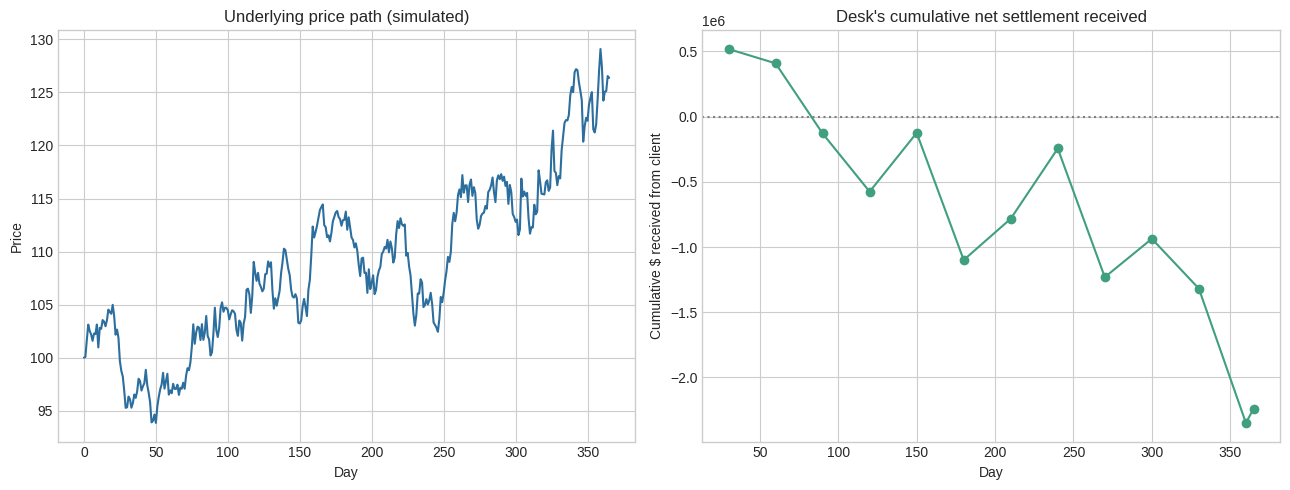

In [2]:
contract = TRSContract(
    notional=10_000_000,
    initial_price=100.0,
    reference_rate=0.045,
    spread=0.0150,      # 150bps financing spread charged to the client
    reset_freq_days=30,
)

# Simulate a full year of daily prices under GBM
paths = gbm_paths(s0=100, mu=0.08, sigma=0.22, T=1.0, n_steps=365, n_paths=1, seed=11)
price_path = paths[0]

daily_div = np.zeros(len(price_path))
for q in [90, 180, 270, 360]:
    daily_div[q] = 0.50  # quarterly dividend

cashflows = simulate_trs_cashflows(contract, price_path, daily_div)

days = [cf.day for cf in cashflows]
net_settlements = [cf.net_settlement for cf in cashflows]
cumulative_desk_pnl = np.cumsum(net_settlements)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(price_path, color="#2c6e9e")
axes[0].set_title("Underlying price path (simulated)")
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Price")

axes[1].plot(days, cumulative_desk_pnl, marker="o", color="#3f9f7f")
axes[1].axhline(0, color="gray", linestyle=":")
axes[1].set_title("Desk's cumulative net settlement received")
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Cumulative $ received from client")

plt.tight_layout()
plt.show()


Notice the desk's cash position moves inversely with the stock price at each
reset — when the stock falls, the client (equity-return receiver) owes the desk
the depreciation on top of the financing spread; when it rises, the desk pays out
the appreciation. **The desk is economically flat to the stock's direction** (that's
the point of being "delta one" as the intermediary) as long as it holds an
offsetting hedge — its actual risk is financing/borrow cost, not price direction.

In [3]:
breakdown = desk_pnl_breakdown(cashflows, actual_borrow_cost=15_000)
for k, v in breakdown.items():
    print(f"{k:<32}{v:>15,.2f}")


total_financing_received             600,000.00
total_price_pnl_paid_to_client     2,637,990.30
total_dividends_paid_to_client       200,000.00
net_settlement_to_desk            -2,237,990.30
actual_borrow_cost                    15,000.00
desk_net_pnl                      -2,252,990.30


## 2. Single Stock Future: fair value and basis trading

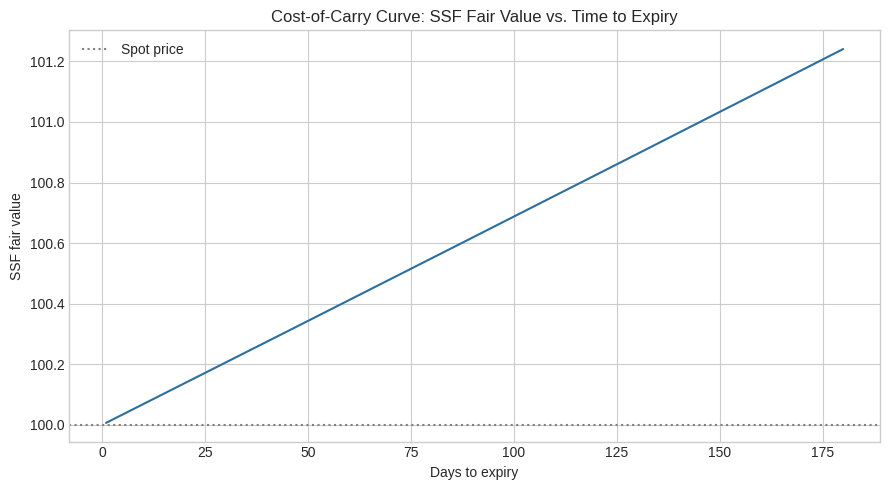

In [4]:
s = 100.0
r_desk = 0.045
q = 0.02
T = 90 / 365

carry_curve_days = np.arange(1, 181)
fair_values = [ssf_fair_value(s, r_desk, q, d/365) for d in carry_curve_days]

plt.figure(figsize=(9, 5))
plt.plot(carry_curve_days, fair_values, color="#2c6e9e")
plt.axhline(s, color="gray", linestyle=":", label="Spot price")
plt.xlabel("Days to expiry")
plt.ylabel("SSF fair value")
plt.title("Cost-of-Carry Curve: SSF Fair Value vs. Time to Expiry")
plt.legend()
plt.tight_layout()
plt.show()


Because the financing rate (4.5%) exceeds the dividend yield (2%) here, the cost
of carry is positive and the future trades at a premium to spot that grows with
time to expiry. If dividend yield exceeded the financing rate, this curve would
slope the other way — the future would trade at a discount ("negative carry").

In [5]:
# A market maker quotes the 3-month future rich relative to the desk's own funding cost
result = basis_trade_pnl(s, f_market=101.30, r_desk=r_desk, q=q, T=T, notional_shares=50_000)
for k, v in result.items():
    print(f"{k:<30}{v}")


fair_value                    100.61834224749413
market_price                  101.3
mispricing_per_share          0.6816577525058705
implied_financing_rate        0.0723824691365486
desk_true_financing_rate      0.045
richness_bps                  273.824691365486
trade_direction               SELL future / BUY stock (cash-and-carry)
arb_profit_per_share          0.6816577525058705
total_arb_profit              34082.88762529352


A 274bps implied-rate richness translates to a ~$34k locked-in arbitrage profit on
just 50,000 shares held to expiry — this is exactly the kind of relative-value
opportunity a delta-one desk is built to identify and act on systematically,
across hundreds of names simultaneously.

## 3. Securities lending: GC vs. special, and the term-vs-overnight decision

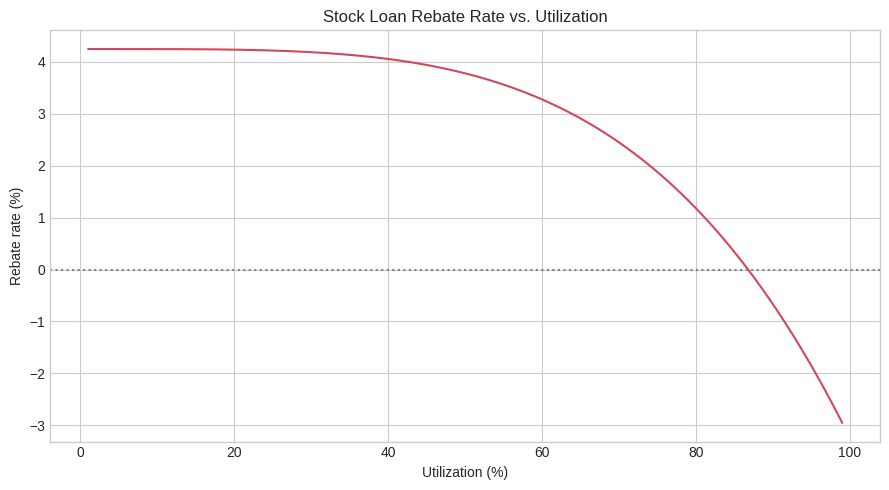

In [6]:
sofr = 0.045
utilization_range = np.linspace(0.01, 0.99, 200)
rebates = [rebate_rate(BorrowQuote('X', sofr, u, days_to_cover=5)) for u in utilization_range]

plt.figure(figsize=(9, 5))
plt.plot(utilization_range * 100, np.array(rebates) * 100, color="#d1495b")
plt.axhline(0, color="gray", linestyle=":")
plt.xlabel("Utilization (%)")
plt.ylabel("Rebate rate (%)")
plt.title("Stock Loan Rebate Rate vs. Utilization")
plt.tight_layout()
plt.show()


This is the shape that defines "going special": rebate stays close to the funding
rate across most of the utilization range (General Collateral), then collapses
sharply — even turning negative — as a stock becomes genuinely hard to borrow.
Negative rebate means the *borrower* pays a fee on top of forgoing collateral
interest, which is exactly what happens in real short squeezes.

In [7]:
easy = BorrowQuote("AAPL", sofr, utilization=0.15, days_to_cover=1.2)
warm = BorrowQuote("GME", sofr, utilization=0.80, days_to_cover=6.0)
special = BorrowQuote("SQUEEZE", sofr, utilization=0.98, days_to_cover=12.0)

for quote in [easy, warm, special]:
    r = rebate_rate(quote)
    print(f"{quote.ticker:<10} util={quote.utilization:.0%}  rebate={r:>8.4%}  -> {classify_borrow(quote)}")


AAPL       util=15%  rebate= 4.2491%  -> General Collateral (GC) — easy to borrow
GME        util=80%  rebate= 0.5636%  -> Warm — moderately hard to borrow
SQUEEZE    util=98%  rebate=-9.5855%  -> Special / Hard-to-Borrow — negative rebate, borrower pays a fee


In [8]:
# Deciding whether to lock in a term borrow ahead of an expected utilization increase
rising_utilization = np.linspace(0.5, 0.95, 14)  # e.g. climbing into an earnings date
decision = term_vs_overnight_decision(warm, term_days=14, expected_utilization_path=rising_utilization)
for k, v in decision.items():
    print(f"{k:<32}{v}")


effective_term_rebate           0.004635999999999995
avg_expected_overnight_rebate   0.012047010283909884
advantage_bps                   -74.11010283909889
recommendation                  ROLL OVERNIGHT


This decision genuinely depends on *levels*, not just direction: locking in
today's rate only wins if today's utilization is already worse than what the
path averages over the term. This is the kind of judgment call a desk actually
has to make when a lender relationship manager is negotiating a term borrow
ahead of a known catalyst (index rebalance, earnings, activist filing).

---
### How this ties together on a real desk

- The desk sells a client **synthetic exposure** via a **TRS**, charging a financing
  spread over its own funding cost.
- To hedge, the desk buys the actual stock — which it may need to **borrow** if
  it's running short elsewhere, or lends out if long, generating **securities
  lending** revenue/cost.
- **SSF** provide an exchange-listed alternative/complement to OTC TRS for the
  same synthetic exposure, and cross-product mispricings (SSF vs. TRS-implied
  financing) are a natural relative-value signal.
- All three are ultimately the same underlying economics — **the financing
  spread and the true cost of carry** — expressed through different instruments.

### Next in this section
- **Corporate actions P&L impact tool**: dividend arbitrage flagging and
  event-driven book risk (matches "idea generation... around corporate actions"
  in the JD).
